In [32]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from datetime import datetime
from Bio import SeqIO
import regex
import hammingdist
import importlib
import transmission_functions as tf
importlib.reload(tf)
import time
from glob import glob
from Bio.SeqRecord import SeqRecord
from Bio import Seq
from matplotlib import pyplot as plt
import scipy as sp
from pathlib import Path
from joblib import Parallel, delayed
import polars as pl
from time import time
import networkx as nx
import pickle
import seaborn as sns

## 1. Generate and save network from sequence and test date data

In [33]:


# Flag for calcualting weighted matrix or not. 
weights = 1
use_edge_weights = True
# Sensitivity analysis or not (this means shifting the generation interval by shift_sensitivity = -2)
sensitivity = 0
low_sr = 0

sensitivity_output_str_list = ['', '_sensitivity']
sensitivity_output_str = sensitivity_output_str_list[sensitivity]
shift_list = [0, -2]
shift_sensitivity = shift_list[sensitivity]
# weights = int(input('Include weights in matrix (input True or False): '))

low_sr_output_str_list = ['', '_low_sr']
low_sr_output_str = low_sr_output_str_list[low_sr]

reweight_zero = False
reweight_zero_str = ['', '_reweight_zero'][int(reweight_zero)]

read_sparse = False

print('Weighted graph = ' + str(weights == 1))
print('Sensitivity Analysis: ' + str(bool(sensitivity)))
print('Reweighting zero: ' + str(reweight_zero) )

sequences_folder = '../data'

# Convert sequences to strings from Seq objects
def convert_to_string(Seq):
    string = str(Seq).upper()
    return regex.sub(r'[^ACTG]', '-', string)



# Max number of days - 21 is a decent cutoff to make transmission >21 days unlikely
ndays = 20 + 1
# Max number of substitutions - 9 is a decent cutoff to make transmission >9 substitutions unlikely. In practice, limit is 2
nsubs = 9
# Substitution rate - subject to sensitivity! On average 1 mutation per 11 days.
if low_sr:
    sr = 0.06
else:
    sr = 1/11
    
days = np.arange(ndays)
subs = np.arange(nsubs)
# prob_mat is a matrix whose (i, j)th entry is the probability that a transmission pair (A, B) has i days between testing and a Hamming distance of j.
prob_mat = np.zeros((ndays, nsubs+1))

for sub in range(nsubs+1):
    for d, day in enumerate(days):

        prob = tf.scenario1_probability(day, sub, sr, shift = shift_sensitivity)
        prob_mat[d, sub] = prob
prob_mat = prob_mat.T
if reweight_zero:
    prob_mat += 5e-6
    prob_mat /= np.sum(prob_mat)

# Function for calculating (unweighted) adjacency matrix - in practice we do not use this any more
def adjacency_matrix(hamming_mat, daydiff_mat, idxs, nseqs):
    infection_adj_mat = np.zeros((nseqs, nseqs))
    for i in range(nseqs):
        for j in range(nseqs):
            infection_adj_mat[i, j] = ((int(hamming_mat[i, j]), daydiff_mat[i, j]) in idxs) * (daydiff_mat[i, j] >= 0) 

    np.fill_diagonal(infection_adj_mat, 0)
    return infection_adj_mat

# Function for calculating weighted adjacency matrix - this forms the network
def weighted_adj_mat(hamming_mat, daydiff_mat, idxs, nseqs, prob_mat):
    weighted_mat = np.zeros((nseqs, nseqs))
    for i in tqdm(range(nseqs)):
        for j in range(nseqs):
            hdist = int(hamming_mat[i, j])
            ddiff = int(daydiff_mat[i, j])
            if (hdist, ddiff) in valid_idxs:
                weighted_mat[i, j] = prob_mat[hdist, ddiff] * (ddiff >= 0) 
    np.fill_diagonal(weighted_mat, 0)
    return weighted_mat
    
# Alternative (more efficient) function for calculating weighted adjacency matrix
def weighted_adj_mat_2(hamming_mat, daydiff_mat, idxs, prob_mat = prob_mat):
    new_dist = hamming_mat
    new_dates = daydiff_mat.astype(int)
    
    valid_distances = [v for (v, d) in idxs]
    valid_daydiffs = [d for (v, d) in idxs]

    invalid_distances = ~np.isin(new_dist, valid_distances)
    invalid_daydiffs =  ~np.isin(new_dates, valid_daydiffs)

    invalid_idxs = invalid_daydiffs + invalid_distances
    weighted_mat = prob_mat[new_dist*(1-invalid_idxs), new_dates*(1-invalid_idxs)]
    np.fill_diagonal(weighted_mat, 0)
    weighted_mat[invalid_idxs] = 0
    return weighted_mat


# Get indices of probability space corresponding to plausible transmission via a Poisson process, based on prob_mat
def get_idxs(ndays = 20 + 1,
            nsubs = 9,
            sr = sr, 
            shift = 0):

    days = np.arange(ndays)
    subs = np.arange(nsubs)
    prob_mat = np.zeros((ndays, nsubs+1))
    for sub in range(nsubs+1):
        for d, day in enumerate(days):

            prob = tf.scenario1_probability(day, sub, sr)
            prob_mat[d, sub] = prob
        # prob_mats += [prob_mat]
    prob_mat = prob_mat.T
    time = np.arange(21)
    cprob = (np.cumsum(tf.gamma_probability_discrete(time)))
    p_cutoff = 0.95
    t_cutoff = time[np.argwhere(cprob > p_cutoff)[0][0]]
    prob_mat_cutoff = np.zeros_like(prob_mat)
    all_subs = np.arange(10)
    inhomogeneous = False
    tdiff1 = 6

    for sub in range(nsubs+1):

        for d, day in enumerate(days):
            cprob_sub = (np.sum(tf.substitution_probability(all_subs[:sub+1], d, sr, inhomogeneous=inhomogeneous)))
            cprob_day = (np.sum(tf.gamma_probability_discrete(time[:d+1], shift = shift)))
            

            prob_mat_cutoff[sub, d] = (int(cprob_sub <= p_cutoff) * int(d <=t_cutoff))
    valid_idxs = [(0, 0)] + list(zip(*np.where(prob_mat_cutoff == 1)))
    return valid_idxs


valid_idxs = get_idxs(shift = shift_sensitivity)


    
    

Weighted graph = True
Sensitivity Analysis: False
Reweighting zero: False


In [34]:
print('Reading Sequences')

seq_path_list = ['../demo_sequences']

# Read in sequences
sequences_path = sequences_folder + '/demo_sequences.fasta'
start = time()
data = SeqIO.parse(sequences_path, "fasta")
records = [(record.id, record.seq) for record in data]
ids, sequences = list(zip(*records))
stop = time()
print('Sequences read in ' + str(stop-start) + ' seconds')
sequences_df = pd.DataFrame({'strain' : ids, 'SeqRecords' : sequences})




# Calculate an adjacency matrix (and, hence, a network)
for sl in tqdm(seq_path_list):
    
    
    print('Calculating adjacency matrix for strain: ' + sl)
    
    
        
        
    start = time()
    #Calculate Hamming distance matrix
    hamming_path_str = "../data/" + 'hamming.csv'
    hamming_path = Path(hamming_path_str)
    if not hamming_path.is_file():

        hammingdist.from_fasta("../data/" + "demo_sequences.fasta", 
                               remove_duplicates = False).dump(hamming_path_str)
    dates_df = pd.read_csv('../data/demo_sample_dates.csv', index_col = [0])
    print('Reading hamming csv')
    if read_sparse:
        hamming_tree = sp.sparse.load_npz("../data/" + 'hamming.csv.npz').toarray()
    else:
        hamming_tree = pd.read_csv(hamming_path, header = None).values
    stop = time()
    print('Hamming Distance matrix calcualted in ' + str(stop-start) + ' seconds')

    start = time()
    nseqs =hamming_tree.shape[0]
    datetimes_first_sample = [datetime.strptime(dstr.split(' ')[0], '%Y-%m-%d') for dstr in dates_df['SampleDateTime'].values]

    # Calculate matrix of date differences matrix
    datediffs = np.zeros((nseqs, nseqs)).astype(int)
    for i, dt in tqdm(enumerate(datetimes_first_sample)):
        for j in range(i):
            datediffs[i, j] = (datetimes_first_sample[i] - datetimes_first_sample[j]).days
                # datediffs should be anti-symmetric
            datediffs[j, i] = - datediffs[i, j]
    end = time()

    print('Date difference matrix calcualted in ' + str(end-start) + ' seconds')
   
    sparse_dates = sp.sparse.csr_matrix(np.tril(datediffs))
  

Reading Sequences
Sequences read in 0.0027768611907958984 seconds


  0%|          | 0/1 [00:00<?, ?it/s]

Calculating adjacency matrix for strain: ../demo_sequences
Reading hamming csv
Hamming Distance matrix calcualted in 0.062116146087646484 seconds


1000it [00:00, 5478.07it/s]
100%|██████████| 1/1 [00:00<00:00,  3.68it/s]

Date difference matrix calcualted in 0.1921858787536621 seconds


In [35]:
print('Calculating adjacency matrix')
if weights == 0:
        
    network_adj_mat = adjacency_matrix(hamming_tree, datediffs, valid_idxs, nseqs=nseqs)
    sparse = sp.sparse.csr_matrix(network_adj_mat)
    sp.sparse.save_npz("../data/adjacency_demo" + sensitivity_output_str + ".npz", sparse)
    sp.sparse.save_npz("../data/dates_demo" + sensitivity_output_str + ".npz", sparse_dates)
else:
    
    start = time()
    network_adj_mat = weighted_adj_mat_2(hamming_tree, datediffs, valid_idxs, prob_mat)
    end = time()
    print('Weighted adjacency matrix calcualted in ' + str(end-start) + ' seconds')
    
    
    sparse = sp.sparse.csr_matrix(network_adj_mat)
    sp.sparse.save_npz("../data/adjacency_demo" 
                        + sensitivity_output_str + reweight_zero_str + low_sr_output_str  +".npz", sparse)
    sp.sparse.save_npz("../data/dates_demo"
                        + sensitivity_output_str + reweight_zero_str + ".npz", sparse_dates)

Calculating adjacency matrix
Weighted adjacency matrix calcualted in 0.032067060470581055 seconds


In [36]:


parallelise = False
n_cores = 8
settings = True
reweight_settings = False
setting_factor_1 = 2
setting_factor_2 = 1
reweight_zero = False
reweight_zero_str = ['', '_reweight_zero'][int(reweight_zero)]
higher_ed = False

print('Prioritise all settings: ' + str(settings))
print('Running sensitivity analysis: ' + str(sensitivity))
print('Reweighting zero: ' + str(reweight_zero))


sl_idx = 0
file_path = '../data/'
sl_list = ['demo']
sl = sl_list[sl_idx]
print('Extracting trees for strain: ' + sl)
# Number of random trees to extract
n_trees = 100
print('Extracting n=' + str(n_trees) + ' trees')

id_path = "../data/demo_ids.csv" 
ids = pl.read_csv(id_path).select(pl.col('strain')).to_numpy().flatten()
ids_df = pl.read_csv(id_path).select(pl.col('strain'))


Prioritise all settings: True
Running sensitivity analysis: 0
Reweighting zero: False
Extracting trees for strain: demo
Extracting n=100 trees


## 2. Sample transmission trees from the network of plausible transmissions

In [37]:
# Read in adjacency matrix calculated previously
start = time()
if sensitivity:
    infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz")
elif reweight_zero:
    infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz")
else:
    infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz")
end = time()
print('Sparse infection matrix read in: ' + str(np.round(end-start, 4)) + ' seconds!')

#### Networkx requires these matrices to be transposed for infector-infectee pairs to be the right way around, hence .T
#### Generate networkx DiGraph object
G_digraph = nx.DiGraph(infection_adj_mat.T, sequence_ids = ids)
####

end2 = time()
print('Digraph created in: ' + str(end2-end) + ' seconds!')

Sparse infection matrix read in: 0.0025 seconds!
Digraph created in: 0.038874149322509766 seconds!


In [38]:
# Get node and edge attributes for network

df_family_edgelist = pl.read_csv('../data/demo_family_edgelist.csv')
family_array = df_family_edgelist.select(pl.col('PERSON_ID_1', 'PERSON_ID_2')).drop_nulls().to_numpy()
family_pairs_set = set([(e, v) for e, v in family_array] + [(v, e) for e, v in family_array])


all_attributes = pl.read_csv('../data/all_attributes.csv')
    
address_ids = ids_df.join(all_attributes, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'UNIQUE_ADDRESS_ID')).to_numpy()

address_attr_dict = dict([(i, address_ids[i, 1]) for i in range(len(address_ids[:, 1]))])

PERSON_ids = ids_df.join(all_attributes, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'PERSON_ID')).to_numpy()

PERSON_ID_attr_dict = dict([(i, PERSON_ids[i, 1]) for i in range(len(PERSON_ids[:, 1]))])
nx.set_node_attributes(G_digraph, PERSON_ID_attr_dict, name = 'PERSON_ID')


all_attributes_work_school = all_attributes.clone()



school_ids = ids_df.join(all_attributes_work_school, 
                         on = 'strain', 
                          how = 'left').select(pl.col('strain', 
                                                      'UDD_ID')).to_numpy()

school_attr_dict = dict([(i, school_ids[i, 1]) for i in range(len(school_ids[:, 1]))])

school_types = ids_df.join(all_attributes_work_school, 
                         on = 'strain', 
                          how = 'left').select(pl.col('strain', 
                                                      'school_type')).to_numpy()
pl.DataFrame(school_types, schema = ['strain', 'school']).write_csv('../data/school_types.csv')
school_types_attr_dict = dict([(i, school_types[i, 1]) for i in range(len(school_types[:, 1]))])

# Workplaces
work_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'ARB_NR')).to_numpy()

work_attr_dict = dict([(i, work_ids[i, 1]) for i in range(len(work_ids[:, 1]))])


kommune_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'KOMMUNE_NAME')).to_numpy()
kommune_attr_dict = dict([(i, kommune_ids[i, 1]) for i in range(len(kommune_ids[:, 1]))])

region_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'Region')).to_numpy()
region_attr_dict = dict([(i, region_ids[i, 1]) for i in range(len(region_ids[:, 1]))])


sample_dates = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'SampleDateTime')).to_numpy()
dates_attr_dict = dict([(i, sample_dates[i, 1]) for i in range(len(sample_dates[:, 1]))])

nx.set_node_attributes(G_digraph, address_attr_dict, name = 'address')
nx.set_node_attributes(G_digraph, school_attr_dict, name = 'school')
nx.set_node_attributes(G_digraph, school_types_attr_dict, name = 'school_type')
nx.set_node_attributes(G_digraph, work_attr_dict, name = 'workplace')
nx.set_node_attributes(G_digraph, kommune_attr_dict, name = 'kommune')
nx.set_node_attributes(G_digraph, region_attr_dict, name = 'region')
nx.set_node_attributes(G_digraph, dates_attr_dict, name = 'SampleDate')

In [39]:
# Assign node and edge attributes

nodes_data = G_digraph.nodes(data = True)
for (start, end) in tqdm(G_digraph.edges):
    start_node = nodes_data[start]
    end_node = nodes_data[end]
    if start_node['address'] == end_node['address']:
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_address')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_address')
        
    if higher_ed == True:

        if start_node['school'] == end_node['school']:
            nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_school')
        else:
            nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_school')
    else:
        if (start_node['school'] == end_node['school'] and 
        (start_node['school_type'] == 'Grundskole' or 
         start_node['school_type'] == 'Gymnasiale uddannelser')):
            
            nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_school')
        else:
            nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_school')

    if start_node['workplace'] == end_node['workplace'] and start_node['workplace'] != 'nan':
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_workplace')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_workplace')
        
    if (start_node['kommune'] == end_node['kommune']) and (end_node['kommune'] != None):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_kommune')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_kommune')
        
    if (start_node['region'] == end_node['region']) and (end_node['region'] != None):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_region')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_region')
        
    if len(set([(start_node['PERSON_ID'],end_node['PERSON_ID']),
            (end_node['PERSON_ID'], start_node['PERSON_ID'])])
           .intersection(family_pairs_set)) > 0:
        
        
        
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'family_relation')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'family_relation')
        



100%|██████████| 28949/28949 [00:00<00:00, 175533.49it/s]


In [40]:
### Functions for sampling random trees

def create_random_sub_tree(G, weighted = True):
    # This function implements the 'random trees' analysis, where data on settings shared by infector and infectee
    # is not taken into account
    G_random = G.copy()
    G_random_nodes = list(G_random.nodes())
    np.random.shuffle(G_random_nodes)
    for node in G_random_nodes:
        edges = G_random.in_edges(node, data = True)
        if len(edges) > 1:
            weights = np.array([edge[2]['weight'] for edge in edges])
            node_idxs = np.arange(len(weights)).astype(int)
            if weighted:
                edge_choice = np.random.choice(node_idxs, p = weights/np.sum(weights))
            else:
                edge_choice = np.random.choice(node_idxs)
            ebunch = []

            ebunch = [(edge[0], edge[1]) for i, edge in enumerate(edges) if i!=edge_choice]
            ebunch += [(edge[1], edge[0]) for edge in ebunch]
            G_random.remove_edges_from(ebunch)
        
    return G_random

def create_random_sub_tree_settings(G, weighted = True, sensitivity = sensitivity):
    # This function implements the 'prioritised settings' analysis, where potential infectors who share a setting 
    # with their potential infectee are prioritised for being sampled as the true infector. 
    G_copy = G.copy()
    G_copy_nodes = list(G_copy.nodes())
    np.random.shuffle(G_copy_nodes)
    for node in G_copy_nodes:
        edges = G_copy.in_edges(node, data = True)
        if len(edges) > 1:
            
            settings = np.array([edge[2]['share_address'] for edge in edges])
            workplaces = np.array([edge[2]['share_workplace'] for edge in edges])  
            schools= np.array([edge[2]['share_school'] for edge in edges])
            families = np.array([edge[2]['family_relation'] for edge in edges])
            weights = np.array([edge[2]['weight'] for edge in edges])
            node_idxs = np.arange(len(edges)).astype(int)
            
            # Households prioritised first
            if (settings).any():
                edge_choice = np.argwhere((settings)).flatten()
                if len(edge_choice)>1:
                    setting_weights = weights[edge_choice]
                    setting_nodes = node_idxs[edge_choice]
                    edge_choice = np.random.choice(setting_nodes, p = setting_weights / np.sum(setting_weights))
                    
            # Then schools and workplaces - assumed equal prioritisation as little to no crossover. 
            elif (workplaces + schools).any():
                edge_choice = np.argwhere((workplaces + schools)).flatten()
                if len(edge_choice)>1:
                    setting_weights = weights[edge_choice]
                    setting_nodes = node_idxs[edge_choice]
                    edge_choice = np.random.choice(setting_nodes, p = setting_weights / np.sum(setting_weights))
            
            # Families explicitly under-prioritised compared to household, school, workplace
            elif families.any():
                edge_choice = np.argwhere((families)).flatten()
                if len(edge_choice)>1:
                    setting_weights = weights[edge_choice]
                    setting_nodes = node_idxs[edge_choice]
                    edge_choice = np.random.choice(setting_nodes, p = setting_weights / np.sum(setting_weights))
                
            else:
                if weighted:
                    edge_choice = np.random.choice(node_idxs, p = weights/np.sum(weights))
                else:
                    edge_choice = np.random.choice(node_idxs)
            ebunch = []

            ebunch = [(edge[0], edge[1]) for i, edge in enumerate(edges) if i!=edge_choice]
            ebunch += [(edge[1], edge[0]) for edge in ebunch]
            

            G_copy.remove_edges_from(ebunch)
            
    return G_copy

def test_graph_serial_intervals(G):
    # Test to avoid any graph negative serial intervals - this will cause an assertion error if you have problems! 
    
    for n, d in G.nodes(data = True):
        assert((d['serial_interval_infector'] >=0 and d['serial_interval_infector'] <= 11) 
               or np.isnan(d['serial_interval_infector'])), 'Found serial intervals outside of generation time: ' + str(d['serial_interval_infector']) 
        return None
    
def convert_to_datediff(e1, e2, G):

    # Convert SampleDates to a datediff
    
    date_e2 = G.nodes[e2]['SampleDate']
    date_e1 = G.nodes[e1]['SampleDate']
    
    # Some of the datediffs are None types - this only affects 57 wildtype sequences, so replace these with np.nan
    
    if date_e1 == None or date_e2 == None:
        return np.nan
    
    else:
        return int((datetime.strptime(date_e2.split('T')[0], '%Y-%m-%d')
                - datetime.strptime(G.nodes[e1]['SampleDate'].split('T')[0], '%Y-%m-%d')).days )
    
def add_out_degree_attributes(nodelist_test):
    
    # Take a sampled tree (given as a polars dataframe representing a nodelist with a list of infectors, 
    # thus creating an edgelist). Add required attributes to each node, in particular giving it an out_degree
    # variable which is the number of infectees from that node. Add other attributes as required.
    
    if 'out_degree_family' in nodelist_test.columns:
        nodelist_test = nodelist_test.drop('out_degree_family')
    if 'out_degree_school' in nodelist_test.columns:
        nodelist_test = nodelist_test.drop('out_degree_school')
    if 'out_degree_workplace' in nodelist_test.columns:
        nodelist_test = nodelist_test.drop('out_degree_workplace')
    if 'out_degree_address' in nodelist_test.columns:
        nodelist_test = nodelist_test.drop('out_degree_address')

    n_nodes = nodelist_test.select(pl.len()).item()#len(nodelist_test)
    person_ids_df = nodelist_test.select(pl.col('PERSON_ID', 'Infector_PERSON_ID'))

    family_pairs = df_family_edgelist.filter(pl.col('PERSON_ID_2')
                                             .is_in(person_ids_df.select('PERSON_ID')
                                                    .to_numpy().flatten())).select(pl.col('PERSON_ID_1', 
                                                                                          'PERSON_ID_2')).to_numpy()

    family_pairs_list_flip = [tuple(i) for i in (np.flip(family_pairs, axis = 1))]#.shape
    family_pairs_list = [tuple(i) for i in (family_pairs)]
    nodelist_pairs = [tuple(i.astype(int)) if not np.isnan(i).any() else np.nan for i in person_ids_df.to_numpy()]

    household_pairs = nodelist_test.filter('Infector_share_address').select(pl.col('PERSON_ID',
                                                                                   'Infector_PERSON_ID')).to_numpy()
    household_pairs = [tuple(i) for i in household_pairs]
    household_pairs_flip = [tuple(i) for i in np.flip(household_pairs, axis = 1)]

    nodelist_test_infectees = nodelist_test.select(pl.col('Infector_ID', 
                                                          'Infector_share_school',
                                                          'Infector_share_address', 
                                                          'Infector_share_workplace',
                                                          'Infector_family_relation'))
    
    nodelist_infectee_breakdown = (nodelist_test_infectees.group_by(pl.col('Infector_ID'))
                                   .sum().select(pl.col('Infector_ID', 
                                                        'Infector_share_school',
                                                        'Infector_share_address', 
                                                        'Infector_share_workplace', 
                                                        'Infector_family_relation')))

    nodelist_infectee_breakdown = nodelist_infectee_breakdown.rename({'Infector_ID' : 'join_id', 
                                                                    'Infector_share_school' : 'out_degree_school', 
                                                                    'Infector_share_address' : 'out_degree_address', 
                                                                    'Infector_share_workplace' : 'out_degree_workplace', 
                                                                     'Infector_family_relation' : 'out_degree_family'})
    if 'index' in nodelist_test.columns:
        nodelist_test = nodelist_test.drop('index')
    nodelist_test = nodelist_test.with_row_index().with_columns(pl.col('index').cast(pl.Float64))
    nodelist_test = nodelist_test.join(nodelist_infectee_breakdown, 
                      left_on = 'index',
                       right_on = 'join_id', 
                       how = 'left').with_columns(pl.col('out_degree_school','out_degree_address',
                                                         'out_degree_workplace', 'out_degree_family').fill_null(0))
    return nodelist_test.to_pandas()

def create_nodelist_from_graph(G_r, attributes_table, output_file):

    # Take a nodelist and create a dataframe with node attributes to be saved as a csv
    
    G = G_r.copy()
    ## attributes_table should contain all of the node attributes that you want. This function extracts them, puts them
    ## in a dictionary and passes them as node attributes to the graph G. 
    
    ##Then makes a dataframe of the attributes and saves as a csv. 

    attributes_table = ids_df.join(attributes_table, on = 'strain', how = 'left')
    out_degrees = dict([(key, val) for key, val in G.out_degree()])
    nx.set_node_attributes(G, out_degrees, name = 'out_degree')
    
    age_attr_dict = dict([(i, a) for (i, a) in enumerate(attributes_table.select(pl.col('Age_at_testing')).to_numpy().flatten())])
    nx.set_node_attributes(G, age_attr_dict, name = 'Age_at_testing')
    # SampleDateTime
    sample_date_dict = dict([(i, a) for (i, a) in enumerate(attributes_table.select(pl.col('SampleDateTime')).to_numpy().flatten())])
    nx.set_node_attributes(G, sample_date_dict, name = 'SampleDate')

    # Regioncode
    region_attr_dict = dict([(i, a) for (i, a) in enumerate(attributes_table.select(pl.col('Regionskode')).to_numpy().flatten())])
    nx.set_node_attributes(G, region_attr_dict, name = 'Regionskode')
    # Kommunecode
    kommune_attr_dict = dict([(i, a) for (i, a) in enumerate(attributes_table.select(pl.col('KOM')).to_numpy().flatten())])
    nx.set_node_attributes(G, kommune_attr_dict, name = 'Kommunekode')
    
    
    addresses = attributes_table.select('UNIQUE_ADDRESS_ID').to_numpy().flatten()
    strain_ids = attributes_table.select('strain').to_numpy().flatten()
    
    address_attr_dict = dict([(i, addresses[i]) for i in range(len(addresses))])
    ids_attr_dict = dict([(i, strain_ids[i]) for i in range(len(strain_ids))])

    nx.set_node_attributes(G, ids_attr_dict, name = 'strain')
    nx.set_node_attributes(G, address_attr_dict, name = 'address')

    
    # Vaccination attributes
    days_since_complete_vaccination = attributes_table.select(pl.col('Days_since_complete_vaccination')).to_numpy().flatten()
    complete_vaccination_before_sampling = attributes_table.select(pl.col('Complete_vaccination_before_sampling')).to_numpy().flatten()

    days_since_first_vaccination = attributes_table.select(pl.col('Days_since_first_vaccination')).to_numpy().flatten()
    first_vaccination_before_sampling = attributes_table.select(pl.col('First_vaccination_before_sampling')).to_numpy().flatten()

    days_since_third_vaccination = attributes_table.select(pl.col('Days_since_third_vaccination')).to_numpy().flatten()
    third_vaccination_before_sampling = attributes_table.select(pl.col('Third_vaccination_before_sampling')).to_numpy().flatten()


    vacc_days_attr_dict = dict([(i, days_since_complete_vaccination[i]) for i in range(len(days_since_complete_vaccination))])
    vacc_complete_attr_dict = dict([(i, complete_vaccination_before_sampling[i]) for i in range(len(complete_vaccination_before_sampling))])

    first_vacc_days_attr_dict = dict([(i, days_since_first_vaccination[i]) for i in range(len(days_since_first_vaccination))])
    first_vacc_attr_dict = dict([(i, first_vaccination_before_sampling[i]) for i in range(len(first_vaccination_before_sampling))])

    third_vacc_days_attr_dict = dict([(i, days_since_third_vaccination[i]) for i in range(len(days_since_third_vaccination))])
    third_vacc_attr_dict = dict([(i, third_vaccination_before_sampling[i]) for i in range(len(third_vaccination_before_sampling))])


    nx.set_node_attributes(G, vacc_days_attr_dict, name = 'days_since_second_vacc')
    nx.set_node_attributes(G, vacc_complete_attr_dict, name = 'second_vacc_complete')
    nx.set_node_attributes(G, first_vacc_days_attr_dict, name = 'days_since_first_vacc')
    nx.set_node_attributes(G, first_vacc_attr_dict, name = 'first_vacc_complete')
    nx.set_node_attributes(G, third_vacc_days_attr_dict, name = 'days_since_third_vacc')
    nx.set_node_attributes(G, third_vacc_attr_dict, name = 'third_vacc_complete')
    
    # Predecessor in the tree
    nodes = G.nodes(data = True)
    predecessor_list = [[(n, p) for p in G.predecessors(n)] if [(n, p) for p in G.predecessors(n)]!= [] else [(n, np.nan)] for n in G.nodes]
    predecessor_dict = dict([l[0] for l in predecessor_list])
    predecessor_id_list = [l[0][1]  for l in predecessor_list]
    predecessor_id_df = pd.DataFrame(predecessor_id_list, columns = ['row_index'])

    
    predecessor_person_id_list = [nodes[int(p)]['PERSON_ID'] if ~np.isnan(p) else np.nan for p in predecessor_dict.values()] 
    predecessor_person_id_dict = dict([(i, idx) for i, idx in enumerate(predecessor_person_id_list)])       
    nx.set_node_attributes(G, predecessor_dict, name = 'Infector_ID')
    nx.set_node_attributes(G, predecessor_person_id_dict, name = 'Infector_PERSON_ID')
     
    share_addresses = [data['share_address'] for (e1, e2, data) in G.edges(data = True) ]
    share_addresses_end = dict([(end, list(G.in_edges(end, data = True))[0][2]['share_address']) for start, end in G.edges])
    nx.set_node_attributes(G, share_addresses_end, name = 'Infector_share_address')
    
    
    share_workplace = [data['share_workplace'] for (e1, e2, data) in G.edges(data = True) ]
    share_workplace_end = dict([(end, list(G.in_edges(end, data = True))[0][2]['share_workplace']) for start, end in G.edges])
    nx.set_node_attributes(G, share_workplace_end, name = 'Infector_share_workplace')
    
    share_school = [data['share_school'] for (e1, e2, data) in G.edges(data = True) ]
    share_school_end = dict([(end, list(G.in_edges(end, data = True))[0][2]['share_school']) for start, end in G.edges])
    nx.set_node_attributes(G, share_school_end, name = 'Infector_share_school')
    
    share_family = [data['family_relation'] for (e1, e2, data) in G.edges(data = True) ]
    share_family_end = dict([(end, list(G.in_edges(end, data = True))[0][2]['family_relation']) for start, end in G.edges])
    nx.set_node_attributes(G, share_family_end, name = 'Infector_family_relation')
    
    nx.set_node_attributes(G, np.nan, name = 'serial_interval_infector')
    serial_intervals = dict([(e2, convert_to_datediff(e1, e2, G)) for (e1, e2) in G.edges])
    nx.set_node_attributes(G, serial_intervals, name = 'serial_interval_infector')
    test_graph_serial_intervals(G)
    
    # Create dataframe of the attributes and save to output_file
    
    node_attr_df = pd.DataFrame.from_dict(dict((G.nodes(data = True))), orient = 'index')
    node_attr_df = add_out_degree_attributes(pl.from_pandas(node_attr_df))
    serial_intervals_df = node_attr_df['serial_interval_infector'].values
    serial_intervals_df = serial_intervals_df[~np.isnan(serial_intervals_df)]
    assert((serial_intervals_df >=0).all()), 'Found negative serial intervals'
    assert((serial_intervals_df <=11).all()), 'Found serial intervals longer than allowed generation time'
    
    
    node_attr_df.to_csv(output_file)
    return None


def create_node_output(G, attributes_table,
                       output_file = None,
                       use_weights = True, 
                       prioritise_settings = settings, 
                      reweight_settings = reweight_settings,
                       setting_factor = None):

    # Single function to create sub tree and then save to csv - for parallelisation - this puts all of the previous
    # functions together, so only one thing to call
    
    if prioritise_settings:
        G_random = create_random_sub_tree_settings(G, weighted = use_weights)
    else:
        G_random = create_random_sub_tree(G, weighted = use_weights)
    create_nodelist_from_graph(G_random, attributes_table, output_file)
    return None

In [41]:
if not parallelise:
    for i in tqdm(range(n_trees)):
        np.random.seed(i)


        if sensitivity:
            output_file_start = '../trees_output/nodelist_' 
        elif reweight_zero:
            output_file_start = '../trees_output/nodelist_' 

        else:
            output_file_start = '../trees_output/nodelist_' 

        create_node_output(G_digraph, all_attributes, output_file = output_file_start + str(i) + '.csv',
                           use_weights = use_edge_weights, prioritise_settings = False)


        if sensitivity:
            output_file_start = '../trees_output/nodelist_'
        elif reweight_zero:
            output_file_start = '../trees_output/nodelist_'
        else:  
            output_file_start = '../trees_output/nodelist_' 
        create_node_output(G_digraph, all_attributes, output_file = output_file_start + str(i) + '.csv',
                           use_weights = use_edge_weights, prioritise_settings = True)

else:
    if sensitivity:
            output_file_start = '../trees_output/nodelist_' 
    else:
        output_file_start = '../trees_output/nodelist_' 
    start = time()

    Parallel(n_jobs = n_cores)(delayed(create_node_output)(G_digraph, all_attributes, output_file = output_file_start + str(i) + '.csv',
                       use_weights = use_edge_weights, prioritise_settings = False) for i in range(n_trees))
    end = time()

    print('Trees without settings sampled in: ' + str(np.round(end-start, 4)) + ' seconds!')

    if sensitivity:
            output_file_start = '../trees_output/nodelist_' 
    else:  
        output_file_start = '../trees_output/nodelist_'
    start = time()       
    Parallel(n_jobs = n_cores)(delayed(create_node_output)(G_digraph, all_attributes, output_file = output_file_start + str(i) + '.csv',
                       use_weights = use_edge_weights, prioritise_settings = True) for i in range(n_trees))

    end = time()

    print('Trees with settings sampled in: ' + str(np.round(end-start, 4)) + ' seconds!')


100%|██████████| 100/100 [00:39<00:00,  2.52it/s]


100%|██████████| 100/100 [00:05<00:00, 18.65it/s]


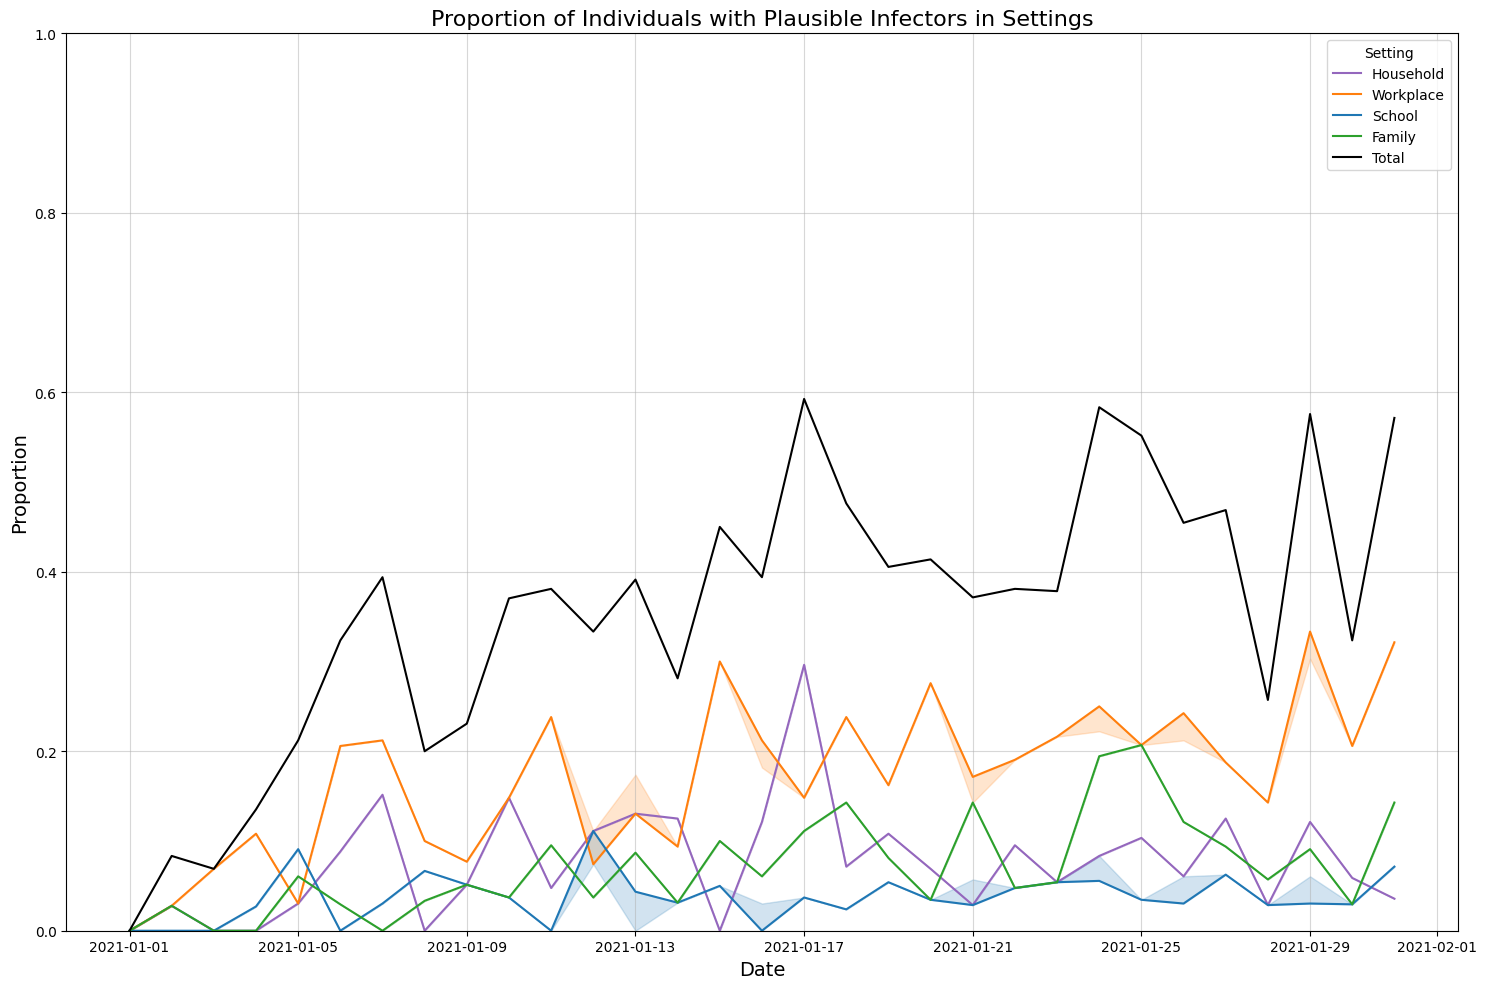

In [42]:
# Proportion of individuals with infectors in different settings

nodelist_test = pl.read_csv('../trees_output/nodelist_'  + str(0) + '.csv').sort('SampleDate')
unique_dates = nodelist_test.select('SampleDate').unique().sort('SampleDate').to_numpy().flatten()
n_trees_plot = n_trees
proportions_household = np.zeros((n_trees_plot, len(unique_dates)))
proportions_school = np.zeros((n_trees_plot, len(unique_dates)))
proportions_workplace = np.zeros((n_trees_plot, len(unique_dates)))
proportions_family = np.zeros((n_trees_plot, len(unique_dates)))

for i in tqdm(range(n_trees_plot)):
    nodelist_test = pl.read_csv('../trees_output/nodelist_'  + str(i) + '.csv').sort('SampleDate')
    date_proportions_household = np.zeros(len(unique_dates))
    date_proportions_school = np.zeros(len(unique_dates))
    date_proportions_workplace = np.zeros(len(unique_dates))
    date_proportions_family = np.zeros(len(unique_dates))

    for j,d in enumerate(unique_dates):

        nodelist_date = nodelist_test.filter(pl.col('SampleDate') == d)
        n_infected_on_date = len(nodelist_date)
        if n_infected_on_date != 0:
            n_household = len(nodelist_date.filter(pl.col('Infector_share_address') == True))

            n_workplace = len(nodelist_date.filter((pl.col('Infector_share_workplace') == True) & 
                                                   (pl.col('Infector_share_address') == False)))
            
            n_school = len(nodelist_date.filter((pl.col('Infector_share_school') == True) & 
                                                (pl.col('Infector_share_workplace') == False) & 
                                                (pl.col('Infector_share_address') == False)))
            
            n_family = len(nodelist_date.filter((pl.col('Infector_family_relation') == True) & 
                                                (pl.col('Infector_share_address') == False) & 
                                                (pl.col('Infector_share_school') == False) & 
                                                (pl.col('Infector_share_workplace') == False)))
            
        
            date_proportions_household[j] = n_household / n_infected_on_date
            date_proportions_workplace[j] = n_workplace / n_infected_on_date
            date_proportions_school[j] = n_school / n_infected_on_date
            date_proportions_family[j] = n_family / n_infected_on_date
    
    proportions_household[i, :] = date_proportions_household
    proportions_school[i, :] = date_proportions_school
    proportions_workplace[i, :] = date_proportions_workplace
    proportions_family[i, :] = date_proportions_family


median_proportions_household = np.median(proportions_household, axis = 0)
median_proportions_workplace = np.median(proportions_workplace, axis = 0)
median_proportions_school = np.median(proportions_school, axis = 0)
median_proportions_family = np.median(proportions_family, axis = 0)

lq_proportions_household = np.quantile(proportions_household, 0.05, axis = 0)
lq_proportions_workplace = np.quantile(proportions_workplace, 0.05, axis = 0)
lq_proportions_school = np.quantile(proportions_school, 0.05, axis = 0)
lq_proportions_family = np.quantile(proportions_family, 0.05, axis = 0)

uq_proportions_household = np.quantile(proportions_household, 0.95, axis = 0)
uq_proportions_workplace = np.quantile(proportions_workplace, 0.95, axis = 0)
uq_proportions_school = np.quantile(proportions_school, 0.95, axis = 0)
uq_proportions_family = np.quantile(proportions_family, 0.95, axis = 0)

plot_dates = unique_dates.astype(np.datetime64)
plt.figure(figsize = (15, 10))
plt.grid(alpha = 0.5)


plt.plot(plot_dates, median_proportions_household, color = 'tab:purple', label = 'Household')
plt.fill_between(plot_dates, lq_proportions_household, uq_proportions_household, color = 'tab:purple', alpha = 0.2)

plt.plot(plot_dates, median_proportions_workplace, color = 'tab:orange', label = 'Workplace')
plt.fill_between(plot_dates, lq_proportions_workplace, uq_proportions_workplace, color = 'tab:orange', alpha = 0.2)

plt.plot(plot_dates, median_proportions_school, color = 'tab:blue', label = 'School')
plt.fill_between(plot_dates, lq_proportions_school, uq_proportions_school, color = 'tab:blue', alpha = 0.2)

plt.plot(plot_dates, median_proportions_family, color = 'tab:green', label = 'Family')
plt.fill_between(plot_dates, lq_proportions_family, uq_proportions_family, color = 'tab:green', alpha = 0.2)
plt.plot(plot_dates, median_proportions_family + 
         median_proportions_household + 
         median_proportions_school + 
         median_proportions_workplace, color = 'black', label = 'Total')

plt.legend(title = 'Setting', loc = 'upper right')
plt.title('Proportion of Individuals with Plausible Infectors in Settings', fontsize = 16)
plt.ylabel('Proportion', fontsize = 14)
plt.xlabel('Date', fontsize = 14)
plt.ylim([0, 1])
plt.tight_layout()

100%|██████████| 100/100 [00:00<00:00, 206.20it/s]


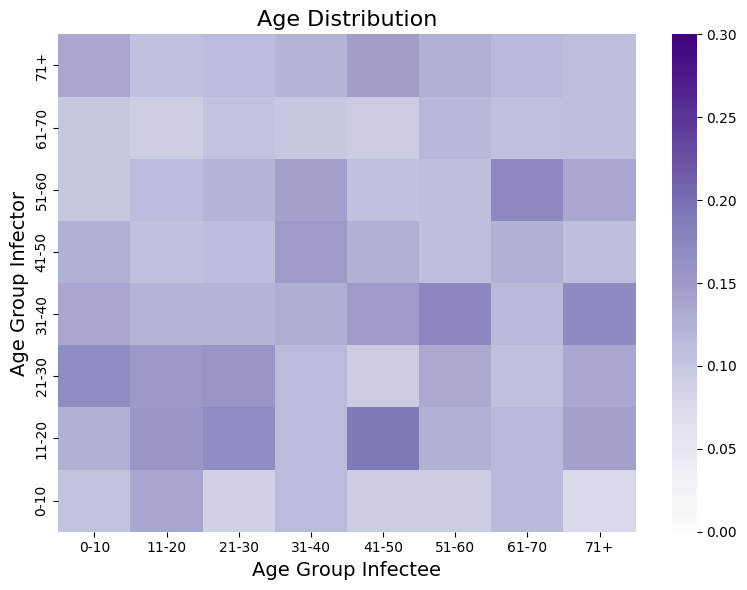

In [43]:
### Age Matrices: 

# Here we just take all settings, but one obtains the matrix for each setting by filtering 
# nodelist_test on the condition e.g. 'Infector_share_school' if one wants the schools matrix:
age_attributes = all_attributes_work_school.select(pl.col('PERSON_ID', 'Age_at_testing'))
maxval_age = 70
def age_groups(n, maxval = maxval_age):
    if n<=maxval:
        return int(n/10)
    else:
        return int(maxval/10)
    
age_group_labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71+']
max_age_group = int(maxval_age/10)
age_mat_all = np.zeros((n_trees_plot, max_age_group+1, max_age_group+1))
for i in tqdm(range(n_trees_plot)):
    age_mat = np.zeros((max_age_group+1, max_age_group+1)) 
    nodelist_test = pl.read_csv('../trees_output/nodelist_'  + 
                                str(i) + 
                                '.csv').sort('SampleDate').with_columns(pl.col('Infector_PERSON_ID').cast(pl.Int64))
    nodelist_test = nodelist_test.join(age_attributes, left_on = 'Infector_PERSON_ID', 
                                       right_on = 'PERSON_ID', how= 'left', suffix = '_infector').filter(~pl.col('Infector_ID').is_null())
    age_groups_vec = nodelist_test.select((pl.col('Age_at_testing_infector', 'Age_at_testing')).map_elements(age_groups)).to_numpy()
    for j in range(age_groups_vec.shape[0]):
        age_group_infector, age_group_infectee = age_groups_vec[j, :]
        age_mat[age_group_infector, age_group_infectee] += 1
    for j in range(max_age_group + 1):
        age_mat[:, j] /= np.sum(age_mat[:, j])
    age_mat_all[i, :, :] = age_mat
age_mat_median = np.median(age_mat_all, axis = 0)
plt.figure(figsize = (8, 6))
fig = sns.heatmap(age_mat_median, cmap = 'Purples', vmin = 0, vmax = .3)
fig.invert_yaxis()
fig.set_xticklabels(age_group_labels)
fig.set_yticklabels(age_group_labels)
plt.title('Age Distribution', fontsize = 16)
plt.xlabel('Age Group Infectee', fontsize= 14)
plt.ylabel('Age Group Infector', fontsize= 14)
plt.tight_layout()

## 3. Generate Transmission Clusters

In [44]:
sl_list = ['demo']
sl_cluster_list = ['demo']

sl = sl_list[sl_idx]
sl_cluster = sl_cluster_list[sl_idx]



school_id_name = 'UDD_ID'
higher_ed = False # Include higher education or only schools and gymnasium


if sl == 'Delta':
    df_family_edgelist = pl.read_csv('../data/demo_family_edgelist.csv')
else:
    df_family_edgelist = pl.read_csv('../data/demo_family_edgelist.csv')
family_pairs = df_family_edgelist.filter(~pl.col('PERSON_ID_1')
                                         .is_null()).select(pl.col('PERSON_ID_1', 'PERSON_ID_2')).to_numpy()

df_family_edgelist = df_family_edgelist.filter(~pl.col('PERSON_ID_1').is_null())
family_array = df_family_edgelist.select(pl.col('PERSON_ID_1', 'PERSON_ID_2')).drop_nulls().to_numpy()
family_pairs_set = set([(e, v) for e, v in family_array] + [(v, e) for e, v in family_array])

In [46]:

if sl == 'Delta':
    id_path = "../data/demo_ids.csv"
else:
    id_path = "../data/demo_ids.csv"
ids = pl.read_csv(id_path).select(pl.col('strain')).to_numpy().flatten()
ids_df = pl.read_csv(id_path).select(pl.col('strain'))
start = time()

if sl == 'Delta':
 
    infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz")
else:
    if sensitivity:
        infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz").T
    else:
        infection_adj_mat = sp.sparse.load_npz("../data/adjacency_demo.npz").T

end = time()
print('Sparse infection matrix read in: ' + str(np.round(end-start, 4)) + ' seconds!')
G_digraph = nx.DiGraph(infection_adj_mat, sequence_ids = ids)
end2 = time()
print('Digraph created in: ' + str(np.round(end2-end, 4)) + ' seconds!')


df_family_edgelist.filter(~(pl.col('PERSON_ID_1') == pl.col('PERSON_ID_2')))
family_pairs = df_family_edgelist.filter(~pl.col('PERSON_ID_1')
                                         .is_null()).select(pl.col('PERSON_ID_1', 'PERSON_ID_2')).to_numpy()

if sl == 'Delta':
    all_attributes = pl.read_csv('../data/all_attributes.csv')
    all_attributes_work_school = pl.read_csv('../data/all_attributes.csv')
else:
    all_attributes = pl.read_csv('../data/all_attributes.csv')
    all_attributes_work_school = pl.read_csv('../data/all_attributes.csv')
school_types = pl.read_csv('../data/school_types.csv')
all_attributes_work_school =  all_attributes_work_school.with_columns(INSTNR = pl.col('UDD_ID'), 
                                                                      UDD = pl.col('UDD_ID'))
all_attributes_work_school = all_attributes_work_school.with_columns(pl.col('INSTNR', 'UDD').cast(str))
all_attributes_work_school = all_attributes_work_school.with_columns(school_id_new = pl.col('INSTNR'))

all_attributes_work_school = all_attributes_work_school.join(school_types,
                                                             left_on = 'strain',
                                                             right_on = 'strain',
                                                             how = 'left')


address_ids = ids_df.join(all_attributes, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'UNIQUE_ADDRESS_ID')).to_numpy()

address_attr_dict = dict([(i, address_ids[i, 1]) for i in range(len(address_ids[:, 1]))])

PERSON_ids = ids_df.join(all_attributes, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'PERSON_ID')).to_numpy()

PERSON_ID_attr_dict = dict([(i, PERSON_ids[i, 1]) for i in range(len(PERSON_ids[:, 1]))])
nx.set_node_attributes(G_digraph, PERSON_ID_attr_dict, name = 'PERSON_ID')




if 'column_0' in all_attributes.columns:
    all_attributes = all_attributes.drop('column_0')
    
if 'column_0' in all_attributes_work_school.columns:
    all_attributes_work_school = all_attributes_work_school.drop('column_0')

school_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'school_id_new')).to_numpy()

school_attr_dict = dict([(i, school_ids[i, 1]) for i in range(len(school_ids[:, 1]))])

school_types = ids_df.join(all_attributes_work_school, 
                         on = 'strain', 
                          how = 'left').select(pl.col('strain', 
                                                      'school_type')).to_numpy()

school_types_attr_dict = dict([(i, school_types[i, 1]) for i in range(len(school_types[:, 1]))])

# Workplaces
work_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'ARB_NR')).to_numpy()

work_attr_dict = dict([(i, work_ids[i, 1]) for i in range(len(work_ids[:, 1]))])


kommune_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'KOMMUNE_NAME')).to_numpy()
kommune_attr_dict = dict([(i, kommune_ids[i, 1]) for i in range(len(kommune_ids[:, 1]))])

region_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'Region')).to_numpy()
region_attr_dict = dict([(i, region_ids[i, 1]) for i in range(len(region_ids[:, 1]))])

dates_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'SampleDateTime')).to_numpy()
dates_attr_dict = dict([(i, dates_ids[i, 1]) for i in range(len(dates_ids[:, 1]))])

nx.set_node_attributes(G_digraph, address_attr_dict, name = 'address')
nx.set_node_attributes(G_digraph, school_attr_dict, name = 'school')
nx.set_node_attributes(G_digraph, school_types_attr_dict, name = 'school_type')
nx.set_node_attributes(G_digraph, work_attr_dict, name = 'workplace')
nx.set_node_attributes(G_digraph, kommune_attr_dict, name = 'kommune')
nx.set_node_attributes(G_digraph, region_attr_dict, name = 'region')
nx.set_node_attributes(G_digraph, dates_attr_dict, name = 'SampleDateTime')
nodes_data = G_digraph.nodes(data = True)
for (start, end) in tqdm(G_digraph.edges):
    start_node = nodes_data[start]
    end_node = nodes_data[end]
    if (start_node['address'] == end_node['address']) and (end_node['address'] != None):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_address')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_address')
        
    if (start_node['kommune'] == end_node['kommune']) and (end_node['kommune'] != None):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_kommune')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_kommune')
        
    if (start_node['region'] == end_node['region']) and (end_node['region'] != None):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_region')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_region')
     
    
    if len(set([(start_node['PERSON_ID'],end_node['PERSON_ID']),
            (end_node['PERSON_ID'], start_node['PERSON_ID'])])
           .intersection(family_pairs_set)) > 0:
        
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'family_relation')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'family_relation')


    if (start_node['school'] == end_node['school']) and (start_node['school_type'] == 'Grundskole' or 
         start_node['school_type'] == 'Gymnasiale uddannelser'):
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_school')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_school')

    if start_node['workplace'] == end_node['workplace'] and start_node['workplace'] != 'nan':
        nx.set_edge_attributes(G_digraph, {(start, end) : True}, name = 'share_workplace')
    else:
        nx.set_edge_attributes(G_digraph, {(start, end) : False}, name = 'share_workplace')


Sparse infection matrix read in: 0.0029 seconds!
Digraph created in: 0.1364 seconds!


100%|██████████| 28949/28949 [00:00<00:00, 179365.19it/s]


In [47]:
all_attributes_work_school = pl.read_csv('../data/all_attributes.csv')
all_attributes_work_school =  all_attributes_work_school.with_columns(INSTNR = pl.col('UDD_ID'), 
                                                                      UDD = pl.col('UDD_ID'))
all_attributes_work_school = all_attributes_work_school.with_columns(pl.col('INSTNR', 'UDD').cast(str))
all_attributes_work_school = all_attributes_work_school.with_columns(school_id_new = pl.col('INSTNR'))
school_types = pl.read_csv('../data/school_types.csv')
all_attributes_work_school = all_attributes_work_school.join(school_types,
                                                             left_on = 'strain',
                                                             right_on = 'strain',
                                                             how = 'left')


In [48]:
# Count number of edges in each setting and compute proportion of overall graph
n_workplaces = len([(e, v) for e, v, d in tqdm(G_digraph.edges(data = True)) if (d['share_workplace'] == True)]) 

n_family = len([(e, v) for e, v, d in G_digraph.edges(data = True) if (d['family_relation'] == True) and
               (d['share_address'] == False)]) 
n_schools = len([(e, v) for e, v, d in G_digraph.edges(data = True) if (d['share_school'] == True)]) 
n_households = len([(e, v) for e, v, d in G_digraph.edges(data = True) if (d['share_address'] == True)]) 

print(np.array((n_workplaces, n_family, n_schools, n_households)) / len(G_digraph.edges) * 100)

100%|██████████| 28949/28949 [00:00<00:00, 2454137.49it/s]

[1.76517324 0.39034164 0.30743722 0.27634806]


In [49]:
ids_attr_dict = dict([(i, PERSON_ids[i, 0]) for i in range(len(PERSON_ids[:, 0]))])

nx.set_node_attributes(G_digraph, 
                       ids_attr_dict,
                       name = 'strain')

sampledates_ids = ids_df.join(all_attributes_work_school, on = 'strain', 
                          how = 'left').select(pl.col('strain', 'SampleDateTime')).to_numpy()

sampledates_attr_dict = dict([(i, 
                               datetime.strptime(sampledates_ids[i, 1].split('T')[0], 
                               '%Y-%m-%d')) for i in range(len(school_ids[:, 1]))])

nx.set_node_attributes(G_digraph, 
                       sampledates_attr_dict,
                       name = 'SampleDateTime')

share_workplace_edges = [(u, v) for u, v, d 
                        in tqdm(G_digraph.edges(data = True)) 
                        if d['share_workplace'] == True]

share_school_edges = [(u, v) for u, v, d 
                     in tqdm(G_digraph.edges(data = True))
                     if d['share_school'] == True]
share_setting_edges = [(u, v) for u, v, d 
                     in tqdm(G_digraph.edges(data = True))
                     if (d['share_school'] == True) or 
                       (d['share_workplace'] == True) or
                      (d['share_address'] == True)]

share_all_setting_edges = [(u, v) for u, v, d 
                     in tqdm(G_digraph.edges(data = True))
                     if (d['share_school'] == True) or 
                       (d['share_workplace'] == True) or
                      (d['share_address'] == True) or
                        (d['family_relation'] == True)  ]

workplace_graph = G_digraph.edge_subgraph(share_workplace_edges)
school_graph = G_digraph.edge_subgraph(share_school_edges)
setting_graph = G_digraph.edge_subgraph(share_all_setting_edges)
wcs_workplace = nx.weakly_connected_components(workplace_graph)
wcs_school = nx.weakly_connected_components(school_graph)
wcs_setting = nx.weakly_connected_components(setting_graph)


wc_sizes_work = np.array([len(wc) for wc in tqdm(wcs_workplace)])
wc_sizes_school = np.array([len(wc) for wc in tqdm(wcs_school)])
wc_sizes_setting = np.array([len(wc) for wc in tqdm(wcs_setting)])

100%|██████████| 28949/28949 [00:00<00:00, 3280404.89it/s]


100%|██████████| 28949/28949 [00:00<00:00, 2965463.59it/s]
3it [00:00, 1039.39it/s]
1it [00:00, 1367.56it/s]
54it [00:00, 8110.74it/s]


In [50]:
# Get components belonging to a particular setting - helper functions

def get_setting_component(component, setting):
    assert(setting in ['school', 'workplace', 'address', 'kommune', 'region', 'family'])
    setting_array = np.array([component.nodes[n][setting] for n in component])
    setting_array = setting_array[setting_array != None]
    unique, num = np.unique(setting_array, return_counts = True)
    return dict(zip(unique, num))

# Get number of individuals in a setting
def get_nsetting_component(component, setting):
    assert(setting in ['school', 'workplace', 'address', 'kommune', 'region'])
    setting_array = np.array([component.nodes[n][setting] for n in component])
    if setting in ['kommune', 'region']:
        setting_set = set(setting_array)
    else:
        setting_set = set(setting_array[~np.isnan(setting_array)])
    return len(setting_set)

# Get dates of tests within a cluster
def get_dates_component(component):
    dates_array = np.array([component.nodes[n]['SampleDateTime'] for n in component])
    ids_array = np.array([component.nodes[n]['strain'] for n in component])
    return dict(zip(ids_array, dates_array))

# Get start and end dates for a cluster
def get_first_last_dates_component(component, include_ids = True):
    dates_array = np.array([component.nodes[n]['SampleDateTime'] for n in component])
    dates_min_idx = np.argmin(dates_array)
    dates_max_idx = np.argmax(dates_array)
    first_date = dates_array[dates_min_idx]
    last_date = dates_array[dates_max_idx]
    ids_array = np.array([component.nodes[n]['strain'] for n in component])
    first_id = ids_array[dates_min_idx]
    last_id = ids_array[dates_max_idx]
    if include_ids:
        return {first_date : first_id, last_date : last_id}
    else: 
        return (first_date, last_date)
        
# Create a dictionary for each cluster with important attributes 
def compose_component_dict(component):
    component_dict = {}
    for setting in (['school', 'workplace', 'address', 'kommune', 'region']):
        component_dict[setting] = get_setting_component(component, setting)
        component_dict[setting] = get_setting_component(component, setting)
    component_dict['start_end_dates'] = get_first_last_dates_component(component, include_ids = True)
    return component_dict

def get_settings_list(component_dict, setting):
    if setting in ['school', 'workplace']:
        return [val for key, val in largest_component_dict[setting].items() if ~np.isnan(key)]
    else:
        return [val for key, val in largest_component_dict[setting].items()]

# Get all pairs that cross into different regions and different municipalities ('kommuner' in Danish)
def get_regions_crossover_lists(component_graph):
    component_kommune_crossovers_ids = [(a,b) for a, b in component_graph.edges() 
                                         if (component_graph.nodes[a]['kommune'] != component_graph.nodes[b]['kommune'])
                                        and (component_graph.nodes[a]['kommune'] != None) 
                                        and (component_graph.nodes[b]['kommune'] != None)]
    component_kommune_crossovers_person_ids = [(component_graph.nodes[a]['PERSON_ID'], component_graph.nodes[b]['PERSON_ID'])
                                   for (a, b) in component_kommune_crossovers_ids]
    component_kommune_crossovers = [(component_graph.nodes[a]['kommune'], component_graph.nodes[b]['kommune'])
                                   for (a, b) in component_kommune_crossovers_ids]
    component_region_crossovers = [(component_graph.nodes[a]['region'], component_graph.nodes[b]['region'])
                                   for (a, b) in component_kommune_crossovers_ids]
    return component_kommune_crossovers_ids, component_kommune_crossovers, component_region_crossovers
    
    


In [51]:
save = 1
all_components_dict = {}
all_components_dict_graph = {}
i=0
size_cutoff = 1
crossover_dict =  {}
for component in tqdm(nx.weakly_connected_components(setting_graph)):
    if len(component) < size_cutoff:
        continue
    component_list = list(component)
    component_graph = setting_graph.subgraph(component_list)
    
    component_dict = compose_component_dict(component_graph)
    
    if i==0:
        clusters_df = pd.DataFrame.from_dict(dict(component_graph.nodes(data = True)), 
                               orient = 'index')
        clusters_df['cluster_number'] = i
    else:
        cluster_df_i = pd.DataFrame.from_dict(dict(component_graph.nodes(data = True)), 
                               orient = 'index')
        cluster_df_i['cluster_number'] = i
        clusters_df = pd.concat([clusters_df, cluster_df_i])
    pd.DataFrame.from_dict(dict(component_graph.nodes(data = True)), 
                           orient = 'index').to_csv('../clusters_output/node_attributes/nodelist_cluster_' + 
                                                    str(i) + '.csv')
    
    component_dict['component_size'] = len(component_graph)
   
    all_components_dict[i] = component_dict
    crossover_ids, crossover_kommuner, crossover_regioner = get_regions_crossover_lists(component_graph)
    if len(crossover_ids) > 0:
        crossover_dict[i] = {'PERSON_IDs' : crossover_ids, 
                            'crossover_kommuner' : crossover_kommuner, 
                            'crossover_regioner' : crossover_regioner}
    component_region_crossovers = [(component_graph.nodes[a]['region'], 
                                      component_graph.nodes[b]['region']) 
                                     for a, b in component_graph.edges() 
                                     if component_graph.nodes[a]['region'] != component_graph.nodes[b]['region']]
    component_kommune_crossovers = [(component_graph.nodes[a]['kommune'], 
                                      component_graph.nodes[b]['kommune']) 
                                     for a, b in component_graph.edges() 
                                     if component_graph.nodes[a]['kommune'] != component_graph.nodes[b]['kommune']]
    all_components_dict_graph[i] = component_dict
    i+=1
    
if save:
    # Nodelist with attributes of all the nodes in clusters with cluster ID 
    clusters_df.to_csv('../clusters_output/node_attributes/nodelist_clusters_no_size_cutoff.csv')

    # Adjacency matrix for all clusters
    sp.sparse.save_npz('../clusters_output/adjacency_matrices/adjacency_settings_macro_school.npz',
                        nx.to_scipy_sparse_array(setting_graph))

    # IDs for all of the nodes in the clusters
    np.savetxt('../clusters_output/adjacency_matrices/settings_network_ids_no_size_cutoff.csv', 
              np.array([d['strain'] for n, d in setting_graph.nodes(data = True)]).astype(str), 
              fmt = '%s')

    # Dictionary with all cluster attributes
    with open('../clusters_output/cluster_dicts/settings_cluster_dict_macro_school.pickle', 'wb') as handle:
        pickle.dump(all_components_dict, handle, protocol = pickle.HIGHEST_PROTOCOL)



54it [00:00, 149.51it/s]


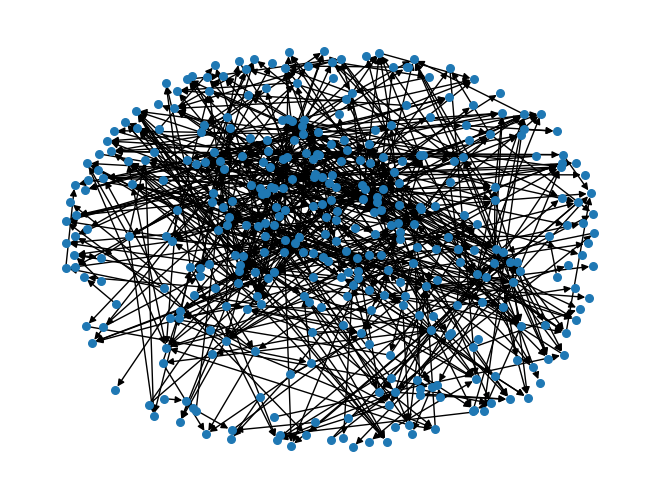

In [52]:
# Visualise cluster 0
pl.from_pandas(clusters_df).filter(pl.col('cluster_number')==0)
cluster_0 = [setting_graph.subgraph(g) for g in nx.weakly_connected_components(setting_graph)][0]
nx.draw(cluster_0, 
        node_size = 30)


## 4. Run Negative Binomial Model

In [53]:
# Load libraries
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.distributions.util import validate_sample
from numpyro.distributions.util import promote_shapes # Useful for broadcasting
from numpyro.infer import MCMC, NUTS
from numpyro.infer import Predictive
from numpyro.infer import init_to_median, init_to_sample, init_to_value
from jax.nn import sigmoid
from jax import random as jax_random # Renamed to avoid conflict if user has 'random' variable
import jax.numpy as jnp
import pandas as pd
import numpy as np
import pickle
import argparse
import arviz as az
import gc


In [54]:
class ZeroInflatedBetaBinomial(dist.Distribution):
    arg_constraints = {
        "gate": constraints.unit_interval,      # Probability of structural zero (psi)
        "total_count": constraints.nonnegative_integer,
        "concentration1": constraints.positive, # Alpha for BetaBinomial
        "concentration0": constraints.positive, # Beta for BetaBinomial
    }
    support = constraints.nonnegative_integer
    has_rsample = False # BetaBinomial itself doesn't have rsample

    def __init__(self, gate, total_count, concentration1, concentration0, validate_args=None):
        """
        Zero-Inflated Beta-Binomial distribution.
        Args:
            gate (Tensor): Probability of structural zero component (often denoted psi).
            total_count (Tensor): Number of trials.
            concentration1 (Tensor): alpha parameter of the Beta distribution.
            concentration0 (Tensor): beta parameter of the Beta distribution.
        """
        self.gate, self.total_count, self.concentration1, self.concentration0 = promote_shapes(
            gate, total_count, concentration1, concentration0
        )
        
        self._beta_binomial_dist = dist.BetaBinomial(
            concentration1=self.concentration1,
            concentration0=self.concentration0,
            total_count=self.total_count
        )
        
        super().__init__(
            batch_shape=self._beta_binomial_dist.batch_shape, # Broadcasting handled by promote_shapes and base dist
            event_shape=self._beta_binomial_dist.event_shape,
            validate_args=validate_args
        )

    def sample(self, key, sample_shape=()):
        key_bern, key_bb = jax_random.split(key)
        
        # gate is Pr(structural zero). is_structural_zero = 1 if it's a structural zero.
        is_structural_zero = dist.Bernoulli(probs=self.gate).sample(key_bern, sample_shape)
        
        # Samples from the BetaBinomial component
        # These samples will have shape: sample_shape + batch_shape
        beta_binom_samples = self._beta_binomial_dist.sample(key_bb, sample_shape)
        
        return jnp.where(is_structural_zero == 1, 0, beta_binom_samples)

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)

        # Log probability from the BetaBinomial component
        log_prob_beta_binom = self._beta_binomial_dist.log_prob(value)

        # log(gate) = log(P(structural zero))
        # log(1-gate) = log(P(not structural zero))
        log_gate = jnp.log(self.gate)
        log_one_minus_gate = jnp.log1p(-self.gate) # Numerically stable log(1-p)

        # For observations where value == 0:
        # log( P(structural_zero) + P(not_structural_zero) * P(BetaBinom=0) )
        # log( gate + (1-gate) * P(BetaBinom=0) )
        # This is logaddexp(log_gate, log_one_minus_gate + log_prob_beta_binom_at_0)
        # Note: log_prob_beta_binom already contains the P(BetaBinom=value), so when value is 0, it's P(BetaBinom=0)
        log_prob_if_zero = jnp.logaddexp(log_gate, log_one_minus_gate + log_prob_beta_binom)

        # For observations where value > 0:
        # log( P(not_structural_zero) * P(BetaBinom=value) )
        log_prob_if_not_zero = log_one_minus_gate + log_prob_beta_binom
        
        return jnp.where(value == 0, log_prob_if_zero, log_prob_if_not_zero)

    @property
    def mean(self):
        # E[Y] = (1 - gate) * E[BetaBinomial]
        return (1 - self.gate) * self._beta_binomial_dist.mean

    @property
    def variance(self):
        # Var[Y] = (1 - gate) * Var(BetaBinomial) + gate * (1 - gate) * (E[BetaBinomial])^2
        e_bb = self._beta_binomial_dist.mean
        var_bb = self._beta_binomial_dist.variance
        return (1 - self.gate) * var_bb + self.gate * (1 - self.gate) * jnp.square(e_bb)



In [55]:
def model(
    out_degree,
    C1_combined_numeric, C2_combined_numeric, C3_combined_numeric, C4_combined_numeric, C6_combined_numeric,
    C8_combined_numeric, H6_combined_numeric, H8_combined_numeric, age_group, vacc_status,
    weeks_since_vacc, variant, Regionskode, is_school_holiday,
    n_variants, n_age_groups, n_vacc_status, n_weeks_since_vacc, n_regions, n_school_holiday, n_trials_address
):
    variant          = jnp.asarray(variant, dtype=jnp.int32)
    age_group        = jnp.asarray(age_group, dtype=jnp.int32)
    vacc_status      = jnp.asarray(vacc_status, dtype=jnp.int32)
    weeks_since_vacc = jnp.asarray(weeks_since_vacc, dtype=jnp.int32)
    
    # Priors for variant (categorical)
    beta_variant      = numpyro.sample("beta_variant", dist.Normal(0, 1).expand((n_variants-1,)))
    beta_variant_full = numpyro.deterministic( "beta_variant_full", jnp.concatenate([jnp.array([0.0]), beta_variant]))
    
    holiday      = numpyro.sample("holiday", dist.Normal(0, 1).expand((n_school_holiday-1,)))
    holiday_full = numpyro.deterministic( "holiday_full", jnp.concatenate([jnp.array([0.0]), holiday]))
    
    # Priors for coefficients specific to each outcome
    beta    = numpyro.sample("beta_school", dist.Normal(0, 1).expand((6,)))  
    
    # Priors for age_group (categorical) with reference group
    # Set the first group (index 0) as the reference group
    beta_age_group      = numpyro.sample("beta_age_group", dist.Normal(0, 1).expand((n_age_groups - 1,)))
    # Pad with 0 for the reference group
    beta_age_group_full = numpyro.deterministic( "beta_age_group_full", jnp.concatenate([jnp.array([0.0]), beta_age_group]))
    
    beta_vacc_status    = numpyro.sample("beta_vacc_status", dist.Normal(0, 1).expand((n_vacc_status - 1,)))
    # Pad with 0 for the reference group
    beta_vacc_status_full = numpyro.deterministic( "beta_vacc_status_full", jnp.concatenate([jnp.array([0.0]), beta_vacc_status]))
    
    # random effects, by setting
    sigma_group = numpyro.sample("sigma_group", dist.HalfNormal(1.0))
    
    with numpyro.plate("groups",n_regions):
      group_intercept = numpyro.sample("group_intercept", dist.Normal(0,sigma_group))
    
    # intercepts
    intercept    = numpyro.sample("intercept", dist.Normal(0,2))
    
    # Priors for hurdle rates 
    hurdle    = numpyro.sample("hurdle", dist.Beta(1,1))
    
    # Overdispersion
    log_alpha    = numpyro.sample("log_alpha", dist.Normal(0,1))
    
    alpha    = numpyro.deterministic("alpha", jnp.exp(log_alpha))
    
    # Linear predictor for out_degree_school
    mu_raw = (
        intercept +
        group_intercept[Regionskode] +
        beta[0] * C1_combined_numeric +
        beta[1] * C2_combined_numeric +
        beta[2] * C4_combined_numeric +
        beta[3] * C6_combined_numeric +
        beta[4] * C8_combined_numeric +
        beta[5] * H6_combined_numeric +
        holiday_full[is_school_holiday] +
        beta_variant_full[variant] +
        beta_vacc_status_full[vacc_status] +
        beta_age_group_full[age_group]   # Use the full beta_age_group with reference group
    )
    mu = numpyro.deterministic("mu", jnp.exp(mu_raw))
    
    numpyro.sample(
       "out_degree", 
       dist.ZeroInflatedNegativeBinomial2(
           gate = hurdle,
           mean = mu,
           concentration = alpha
       ), 
       obs=out_degree)
    
def jittered_init(site, num_samples=10):
    base_init = init_to_median(num_samples=10)(site)
    if hasattr(base_init, 'shape'):
        jitter = 0.1 * jax_random.normal(jax_random.PRNGKey(0), base_init.shape)
        return base_init + jitter
    return base_init




In [62]:
input_file = '../trees_output/nodelist_0.csv'
def main(num_warmup=1000, num_samples=2000, num_chains=4, thinning=10,output_file='mcmc_object_zibb_total_transmission_re'):
    print(f"input_file: {input_file}")
    
    data_rt_ml = pd.read_csv(input_file)
    data_rt_ml['variant'] = 'variant_1'

    # variant
    custom_order_variant           = ['variant_1']
    cat_variant                    = pd.Categorical(data_rt_ml['variant'],categories=custom_order_variant)
    data_rt_ml['variant']          = cat_variant.codes

    # # Regionskode
    custom_order_region            = [1]
    cat_region                     = pd.Categorical(data_rt_ml['Regionskode'],categories=custom_order_region)
    data_rt_ml['Regionskode']     = cat_region.codes

    # # age group

    def age_groups(n):
        if n >60:
            return 0
        elif n>= 40:
            return 1
        elif n >= 19:
            return 2
        elif n >= 11:
            return 3
        else:
            return 4
    
    data_rt_ml['age_group'] = data_rt_ml['Age_at_testing'].apply(age_groups)
    cat_age                        = pd.Categorical(data_rt_ml['age_group'])
    cat_age                        = cat_age.reorder_categories(cat_age.categories[::-1])
    data_rt_ml['age_group']        = cat_age.codes

    # # vaccination status

    def convert_vacc_status(n):
        if n == 0:
            return 'unvaccinated'
        elif n == 1:
            return 'first_vacc'
        else:
            return 'second_vacc'
    data_rt_ml['vacc_status'] = data_rt_ml['first_vacc_complete'] + data_rt_ml['second_vacc_complete']
    data_rt_ml['vacc_status'] = data_rt_ml['vacc_status'].apply(convert_vacc_status)

    custom_order_vacc_status       = ['unvaccinated','first_vacc','second_vacc']
    cat_vacc_status                = pd.Categorical(data_rt_ml['vacc_status'],categories=custom_order_vacc_status)
    data_rt_ml['vacc_status']      = cat_vacc_status.codes

    def school_holiday(d):
        if d< '2021-01-10':
            return 1
        else:
            return 0
    def variants(d):
        if d< '2021-01-10':
            return 'variant_1'
        else:
            return 'variant_2'
    def weeks_since_vac(n):
        if ~np.isnan(n):
            return int(n / 7)
        else:
            return 0
        

    data_rt_ml["is_school_holiday"] = data_rt_ml["SampleDate"].apply(school_holiday)
    data_rt_ml["weeks_since_vacc"] = data_rt_ml["days_since_first_vacc"].apply(weeks_since_vac)
    n_variants = int(np.max(data_rt_ml["variant"].to_numpy()) +1)
    n_regions = int(np.max(data_rt_ml["Regionskode"].to_numpy()) +1)
    n_age_groups = int(np.max(data_rt_ml["age_group"].to_numpy()) +1)
    n_vacc_status = int(np.max(data_rt_ml["vacc_status"].to_numpy()) +1)
    n_weeks_since_vacc = int(np.max(data_rt_ml["weeks_since_vacc"].to_numpy()) +1) 
    n_school_holiday = int(np.max(data_rt_ml["is_school_holiday"].to_numpy()) +1) 

    # Add in NPIs
    def generate_simulated_NPIs(d, date_start, date_end):
        if d >= date_start and d<= date_end:
            return 1
        else:
            return 0

    data_rt_ml['C1_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-15'))
    data_rt_ml['C2_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-10'))
    data_rt_ml['C3_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-12'))
    data_rt_ml['C4_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-25'))
    data_rt_ml['C6_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-01', '2021-01-15'))
    data_rt_ml['C8_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-15'))
    data_rt_ml['H6_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-01', '2021-01-15'))
    data_rt_ml['H8_combined_numeric'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                        args = ('2021-01-05', '2021-01-15'))

    hsize_small_join = data_rt_ml.groupby('address').count().filter(['strain']).rename(columns = 
                                                                                   {'strain' : 'hsize_small'})
    data_rt_ml = data_rt_ml.merge(hsize_small_join, on = 'address')

    data_rt_ml['ContainmentHealthIndex'] = data_rt_ml['SampleDate'].apply(generate_simulated_NPIs, 
                                                                    args = ('2021-01-01', '2021-01-20'))


    data_rt_ml.to_csv('../data/node_attrs.csv')

    # Data preparation
    data = {
        "out_degree": jnp.array(data_rt_ml["out_degree"].to_numpy()), 
        "C1_combined_numeric": jnp.array(data_rt_ml["C1_combined_numeric"].to_numpy()),
        "C2_combined_numeric": jnp.array(data_rt_ml["C2_combined_numeric"].to_numpy()),
        "C3_combined_numeric": jnp.array(data_rt_ml["C3_combined_numeric"].to_numpy()),
        "C4_combined_numeric": jnp.array(data_rt_ml["C4_combined_numeric"].to_numpy()),
        "C6_combined_numeric": jnp.array(data_rt_ml["C6_combined_numeric"].to_numpy()),
        "C8_combined_numeric": jnp.array(data_rt_ml["C8_combined_numeric"].to_numpy()),
        "H6_combined_numeric": jnp.array(data_rt_ml["H6_combined_numeric"].to_numpy()),
        "H8_combined_numeric": jnp.array(data_rt_ml["H8_combined_numeric"].to_numpy()),
        "age_group": jnp.array(data_rt_ml["age_group"].to_numpy(),dtype=jnp.int32),
        "vacc_status": jnp.array(data_rt_ml["vacc_status"].to_numpy(),dtype=jnp.int32),
        "weeks_since_vacc": jnp.array(data_rt_ml["weeks_since_vacc"].to_numpy(),dtype=jnp.int32),
        "variant": jnp.array(data_rt_ml["variant"].to_numpy(),dtype=jnp.int32),
        "Regionskode": jnp.array(data_rt_ml["Regionskode"].to_numpy(),dtype=jnp.int32),
        "is_school_holiday": jnp.array(data_rt_ml["is_school_holiday"].to_numpy(),dtype=jnp.int32),
        "n_variants": n_variants,
        "n_age_groups": n_age_groups,
        "n_vacc_status": n_vacc_status,
        "n_weeks_since_vacc": n_weeks_since_vacc,
        "n_regions": n_regions,
        "n_school_holiday": n_school_holiday,
        "n_trials_address": jnp.array(data_rt_ml["hsize_small"].to_numpy(),dtype=jnp.int32)
    }
    numpyro.set_host_device_count(num_chains)
    rng_key = jax_random.PRNGKey(0)
    kernel = NUTS(model, init_strategy=init_to_median(num_samples=50))         # Add small noise to break symmetry and avoid exact same starting points
    mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, thinning=thinning, num_chains=num_chains,chain_method='parallel')
    mcmc.run(rng_key, **data)

    del data
    gc.collect()

    summary = az.summary(mcmc, hdi_prob = 0.95)
    summary.to_csv(f"{output_file}_summary.csv")

    inference_data = az.from_numpyro(mcmc)
    inference_data.to_netcdf(f"{output_file}_results.nc", engine = 'netcdf4')

    

In [63]:
pl.read_csv('../trees_output/nodelist_0.csv')

,index,PERSON_ID,address,school,school_type,workplace,kommune,region,SampleDate,out_degree,Age_at_testing,Regionskode,Kommunekode,strain,days_since_second_vacc,second_vacc_complete,days_since_first_vacc,first_vacc_complete,days_since_third_vacc,third_vacc_complete,Infector_ID,Infector_PERSON_ID,Infector_share_address,Infector_share_workplace,Infector_share_school,Infector_family_relation,serial_interval_infector,out_degree_school,out_degree_address,out_degree_workplace,out_degree_family
i64,f64,i64,str,str,str,str,i64,i64,str,i64,i64,i64,i64,str,f64,i64,f64,i64,f64,i64,f64,f64,bool,bool,bool,bool,f64,i64,i64,i64,i64
0,0.0,0,"""address_303""","""nan""","""nan""","""workplace_B""",1,1,"""2021-01-06""",3,67,1,1,"""sequence_0""",5.0,1,27.0,1,9.0,1,211.0,211.0,false,true,false,false,1.0,0,0,1,0
1,1.0,1,"""address_211""","""school_C""","""Gymnasiale uddannelse""","""nan""",1,1,"""2021-01-28""",0,3,1,1,"""sequence_1""",null,0,31.0,1,null,0,976.0,976.0,false,false,false,false,5.0,0,0,0,0
2,2.0,2,"""address_294""","""nan""","""nan""","""workplace_A""",1,1,"""2021-01-16""",2,5,1,1,"""sequence_2""",21.0,1,48.0,1,22.0,1,877.0,877.0,false,true,false,false,6.0,0,0,2,0
3,3.0,3,"""address_53""","""nan""","""nan""","""nan""",1,1,"""2021-01-27""",0,15,1,1,"""sequence_3""",1.0,1,8.0,1,58.0,1,239.0,239.0,true,false,false,false,11.0,0,0,0,0
4,4.0,4,"""address_204""","""nan""","""nan""","""nan""",1,1,"""2021-01-20""",0,31,1,1,"""sequence_4""",null,0,28.0,1,null,0,302.0,302.0,false,false,false,false,9.0,0,0,0,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
995,995.0,995,"""address_104""","""nan""","""nan""","""workplace_C""",1,1,"""2021-01-18""",1,60,1,1,"""sequence_995""",null,0,47.0,1,null,0,368.0,368.0,false,true,false,false,7.0,0,0,0,0
996,996.0,996,"""address_64""","""nan""","""nan""","""nan""",1,1,"""2021-01-08""",2,48,1,1,"""sequence_996""",null,0,48.0,1,null,0,800.0,800.0,false,false,false,false,5.0,0,0,0,1
997,997.0,997,"""address_100""","""school_A""","""Grundskole""","""nan""",1,1,"""2021-01-02""",5,4,1,1,"""sequence_997""",57.0,1,29.0,1,44.0,1,690.0,690.0,false,false,false,false,1.0,4,0,0,0


In [64]:
output_file = './demo_npi_effects'
main(
    )

input_file: ../trees_output/nodelist_0.csv


/var/folders/kl/w7r55vs90c58xkf3cv9vb48c0000gp/T/ipykernel_1219/1291321385.py:141: UserWarning: There are not enough devices to run parallel chains: expected 4 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(4)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  mcmc = MCMC(kernel, num_warmup=num_warmup, num_samples=num_samples, thinning=thinning, num_chains=num_chains,chain_method='parallel')
sample: 100%|██████████| 3000/3000 [01:08<00:00, 43.64it/s, 143 steps of size 2.66e-02. acc. prob=0.92]
/Users/jaccur/miniconda3/envs/d3p2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:596: RuntimeWarning: invalid value encountered in scalar divide
  (between_chain_variance / within_chain_variance + num_samples - 1) / (num_samples)
/Users/jaccur/miniconda3/envs/d3p2/lib/python3.14/site-packages/arviz/stats/diagnostics.py:991: R